In [1]:
import os
import sys

if os.getcwd().endswith("notebooks"):
    os.chdir("..")

sys.path.append(os.path.abspath("./"))

print(f"Current work directory: {os.getcwd()}")

Current work directory: C:\Users\yyyyx\Work\OC43_machine_learning\Regression_Modeling_of_OC43_Coronavirus_Viral_Burden_from_Host_Single-cell_Transcriptomes_Using_Explainable_Machine_Learning


In [2]:
from sklearn.pipeline import Pipeline
import pandas as pd
from catboost import Pool, CatBoostRegressor
import matplotlib.pyplot as plt
import numpy as np
import shap
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.model_selection import learning_curve, KFold, cross_val_score
import time
import joblib
import optuna
from scipy import stats
import scripts.plotting as pl
import scripts.optimization as opt

## 1. Training data preprocessing

In [3]:
train_df = pd.read_csv('./CSV/train_df_260421.csv')

In [4]:
test_df = pd.read_csv('./CSV/test_df_260421.csv')

In [5]:
genes_of_interest = [
   'ACTB','TPI1','FTL','RPS7','PPIA','SNHG1','SNHG7','IFRD1','HSPA5','ATP5MF','target'
   ]

In [6]:
train_df_top10 = train_df[genes_of_interest].copy()

In [7]:
test_df_top10 = test_df[genes_of_interest].copy()

In [8]:
X_train = train_df_top10.drop('target', axis=1)
y_train = train_df_top10['target']
feature_names = X_train.columns.tolist()

## 2. Adjusting the weights of the initial 10 genes using Optuna

In [9]:
# ---------------------------------------------------------
# Step 1: Feature Weight Optimization
# ---------------------------------------------------------

# Initial weights
initial_weights_dict = {
    'ACTB' : 14.83, 'TPI1' : 9.43, 'FTL' : 4.24,
    'RPS7' : 4.02, 'PPIA' : 3.17, 'SNHG1' : 1.96,
    'SNHG7' : 1.51, 'IFRD1' : 1.34, 'HSPA5' : 1.25, 'ATP5MF' : 1.12
}

best_weights_map, study_weights = opt.tune_feature_weights(
    X=X_train, 
    y=y_train, 
    seed = 42,
    feature_names=X_train.columns.tolist(),
    initial_weights=initial_weights_dict,
    n_trials=100
)

print("\nBest Weights Found:")
print(best_weights_map)

[I 2026-04-30 14:22:25,593] A new study created in memory with name: no-name-94f4bb25-bfeb-4511-acba-5dcb3e62414d


ℹ️ Enqueued initial weights for 10 features.
🚀 Starting Feature Weight Optimization (100 trials)...


[I 2026-04-30 14:22:32,401] Trial 0 finished with value: 0.7317266001919798 and parameters: {'weight_ACTB': 14.83, 'weight_TPI1': 9.43, 'weight_FTL': 4.24, 'weight_RPS7': 4.02, 'weight_PPIA': 3.17, 'weight_SNHG1': 1.96, 'weight_SNHG7': 1.51, 'weight_IFRD1': 1.34, 'weight_HSPA5': 1.25, 'weight_ATP5MF': 1.12}. Best is trial 0 with value: 0.7317266001919798.
[I 2026-04-30 14:22:39,171] Trial 1 finished with value: 0.7323802084155077 and parameters: {'weight_ACTB': 5.930831723286756, 'weight_TPI1': 14.285357442943784, 'weight_FTL': 11.113912156265373, 'weight_RPS7': 9.180548020857032, 'weight_PPIA': 2.7622702864153297, 'weight_SNHG1': 2.7619205448749384, 'weight_SNHG7': 1.3422123764388922, 'weight_IFRD1': 13.05955411373656, 'weight_HSPA5': 9.216167670276528, 'weight_ATP5MF': 10.76705237804266}. Best is trial 1 with value: 0.7323802084155077.
[I 2026-04-30 14:22:45,811] Trial 2 finished with value: 0.7357128704986017 and parameters: {'weight_ACTB': 0.7984751672891355, 'weight_TPI1': 14.5636

✅ Optimization Complete. Best R2: 0.7412

Best Weights Found:
{'ACTB': 13.128773980270903, 'TPI1': 10.377941728584243, 'FTL': 11.917670108458983, 'RPS7': 12.360502538659553, 'PPIA': 10.485336374931736, 'SNHG1': 14.983831638407512, 'SNHG7': 10.985691155517122, 'IFRD1': 9.386877644776515, 'HSPA5': 14.211918114036454, 'ATP5MF': 5.828818151728862}


In [10]:
# ---------------------------------------------------------
# Step 2: Hyperparameter Optimization (with fixed weights)
# ---------------------------------------------------------

best_params, study_params = opt.tune_hyperparameters(
    X=X_train,
    y=y_train,
    seed = 42,
    feature_weights=best_weights_map,
    n_trials=100
)

print("\nBest Hyperparameters:")
print(best_params)

[I 2026-04-30 14:33:33,425] A new study created in memory with name: no-name-57171b25-0db1-45ba-8aeb-f4ee67dc7b5b


🚀 Starting Hyperparameter Tuning (100 trials)...


[I 2026-04-30 14:33:39,968] Trial 0 finished with value: 0.7377983611187686 and parameters: {'depth': 6, 'l2_leaf_reg': 22.648248189516845, 'learning_rate': 0.08960785365368121}. Best is trial 0 with value: 0.7377983611187686.
[I 2026-04-30 14:33:48,901] Trial 1 finished with value: 0.7453383732534068 and parameters: {'depth': 7, 'l2_leaf_reg': 0.24348773534554594, 'learning_rate': 0.015957084694148364}. Best is trial 1 with value: 0.7453383732534068.
[I 2026-04-30 14:33:52,940] Trial 2 finished with value: 0.7434092647864379 and parameters: {'depth': 4, 'l2_leaf_reg': 13.983740016490973, 'learning_rate': 0.06054365855469246}. Best is trial 1 with value: 0.7453383732534068.
[I 2026-04-30 14:34:06,471] Trial 3 finished with value: 0.7066310425116213 and parameters: {'depth': 8, 'l2_leaf_reg': 0.11245798259119336, 'learning_rate': 0.18276027831785724}. Best is trial 1 with value: 0.7453383732534068.
[I 2026-04-30 14:34:19,809] Trial 4 finished with value: 0.7447708631640262 and parameter

✅ Tuning Complete. Best R2: 0.7471

Best Hyperparameters:
{'depth': 7, 'l2_leaf_reg': 1.418247300040315, 'learning_rate': 0.012542635400152841}


## 3. Final model train

In [11]:
#-----------------------------------
# Create and train the tuned model.
#-----------------------------------
print("\nCreate and train the final model with optimal weights and regularization parameters...")

final_weights = [best_weights_map[col] for col in X_train.columns]

print(final_weights)

final_model = CatBoostRegressor(
    iterations=1000,
    random_state=42,
    verbose=0,
    allow_writing_files=False,
    depth=best_params['depth'],
    l2_leaf_reg=best_params['l2_leaf_reg'],
    learning_rate=best_params['learning_rate'],
    feature_weights=final_weights
)

final_model.fit(X_train, y_train)

print("✅ Model training completed.")
print(f"  - Applied Depth: {final_model.get_param('depth')}")
print(f"  - Applied Learning Rate: {final_model.get_param('learning_rate')}")


Create and train the final model with optimal weights and regularization parameters...
[13.128773980270903, 10.377941728584243, 11.917670108458983, 12.360502538659553, 10.485336374931736, 14.983831638407512, 10.985691155517122, 9.386877644776515, 14.211918114036454, 5.828818151728862]
✅ Model training completed.
  - Applied Depth: 7
  - Applied Learning Rate: 0.012542635400152841


In [12]:
joblib.dump(final_model,'./Data/model/Compact_cat_after_tunning_260421.pkl')

['./Data/model/Compact_cat_after_tunning_260421.pkl']

In [13]:
final_model = joblib.load('./Data/model/Compact_cat_after_tunning_260421.pkl')

In [14]:
final_model

## 4. Check model performance and learning curve

In [15]:
target_col = 'target' 

X_test = test_df_top10.drop(columns=[target_col])
y_test = test_df_top10[target_col]

y_pred = final_model.predict(X_test)

In [16]:
# ---------------------------------------------------------
# 1. Model Evaluation Metrics
# ---------------------------------------------------------
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("="*30)
print(f"Model Performance (Test Set)")
print("="*30)
print(f"MAE  (Mean Absolute Error)     : {mae:.4f}")
print(f"MSE  (Mean Squared Error)      : {mse:.4f}")
print(f"RMSE (Root Mean Squared Error) : {rmse:.4f}")
print(f"R2 Score (Coefficient of Det.) : {r2:.4f}")
print("="*30)

Model Performance (Test Set)
MAE  (Mean Absolute Error)     : 0.6671
MSE  (Mean Squared Error)      : 0.7858
RMSE (Root Mean Squared Error) : 0.8865
R2 Score (Coefficient of Det.) : 0.7439


In [17]:
actual = y_test.values
predicted = y_pred

In [18]:
pl.set_publication_style()

(<Figure size 1500x1500 with 1 Axes>,
 <Axes: xlabel='Actual value', ylabel='Predicted value'>)

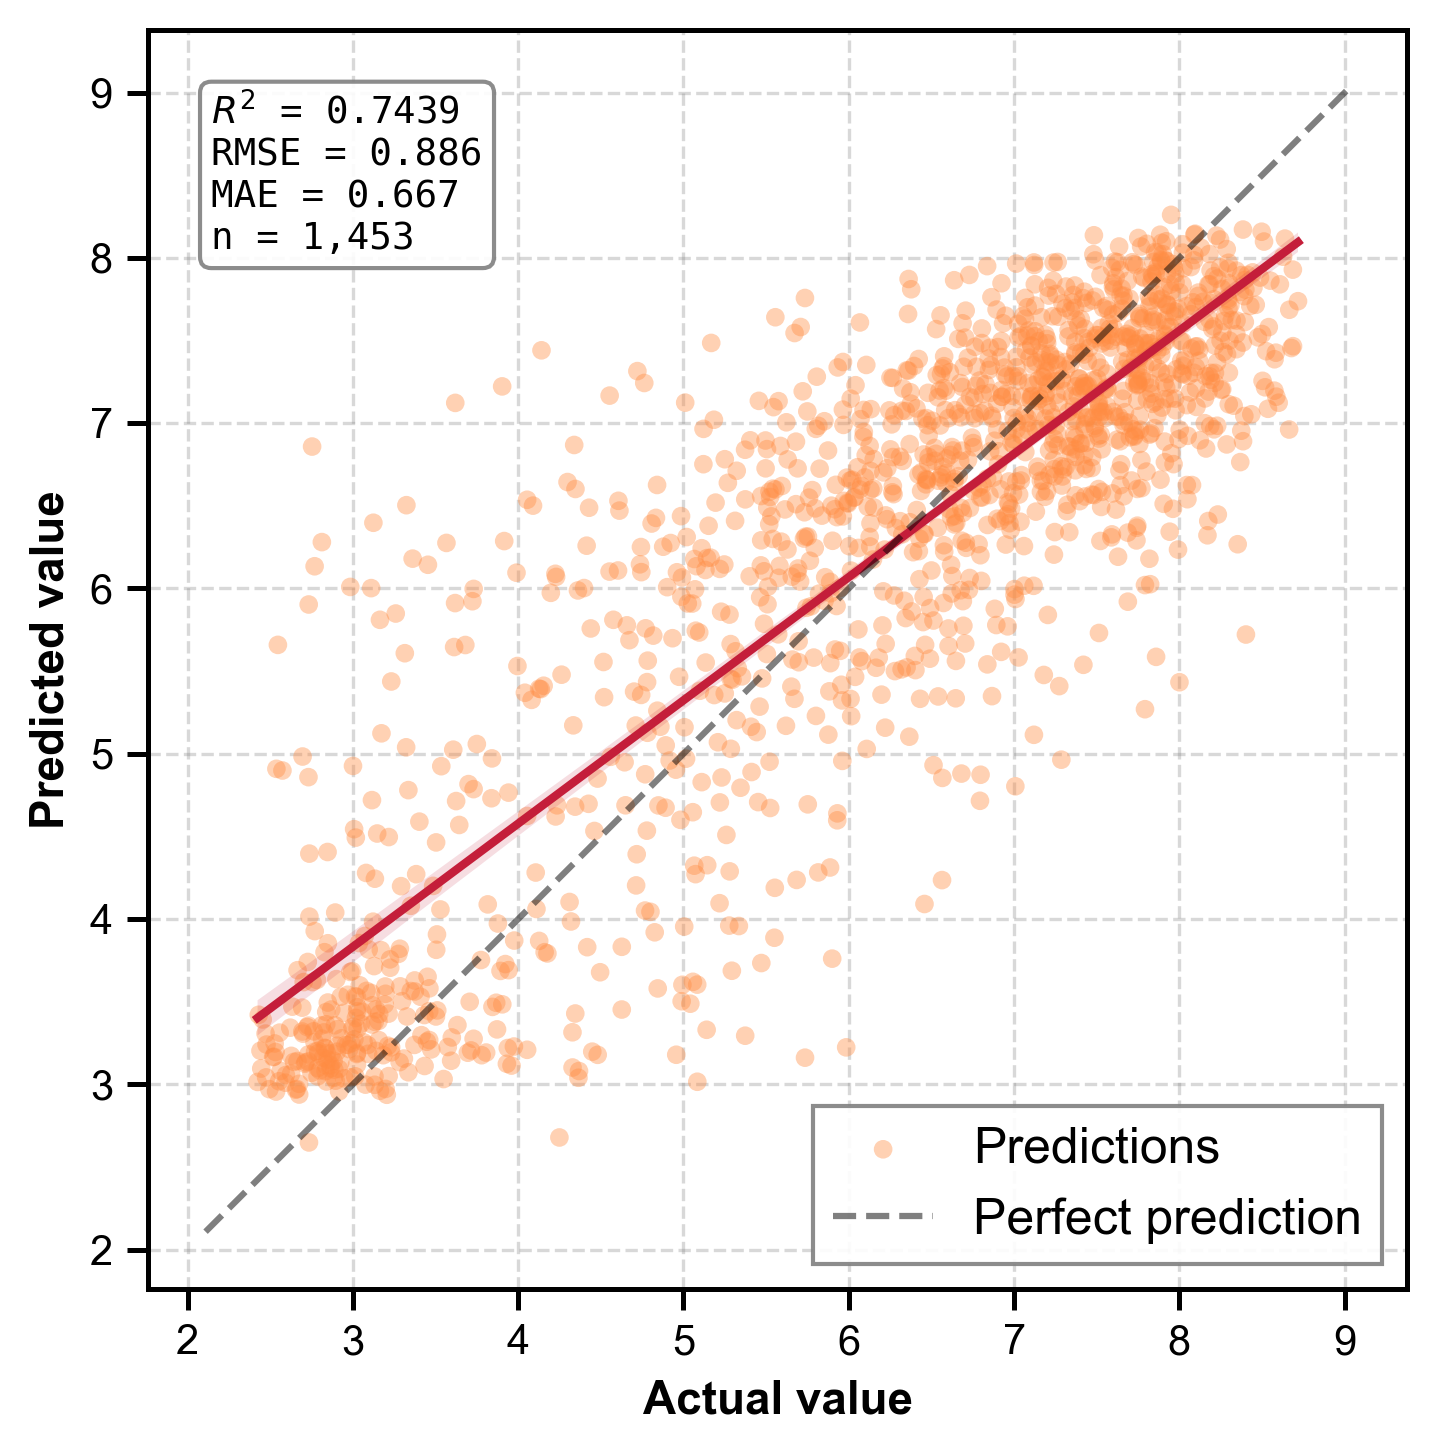

In [19]:
pl.plot_performance_scatter(y_true=actual, y_pred=predicted,save_path='./Plot/Compact_catboost_scatter_performance_260421.png')

Generating learning curve...
Learning curve generated in 31.4s
Final Training R2: 0.8243
Final Validation R2: 0.5935


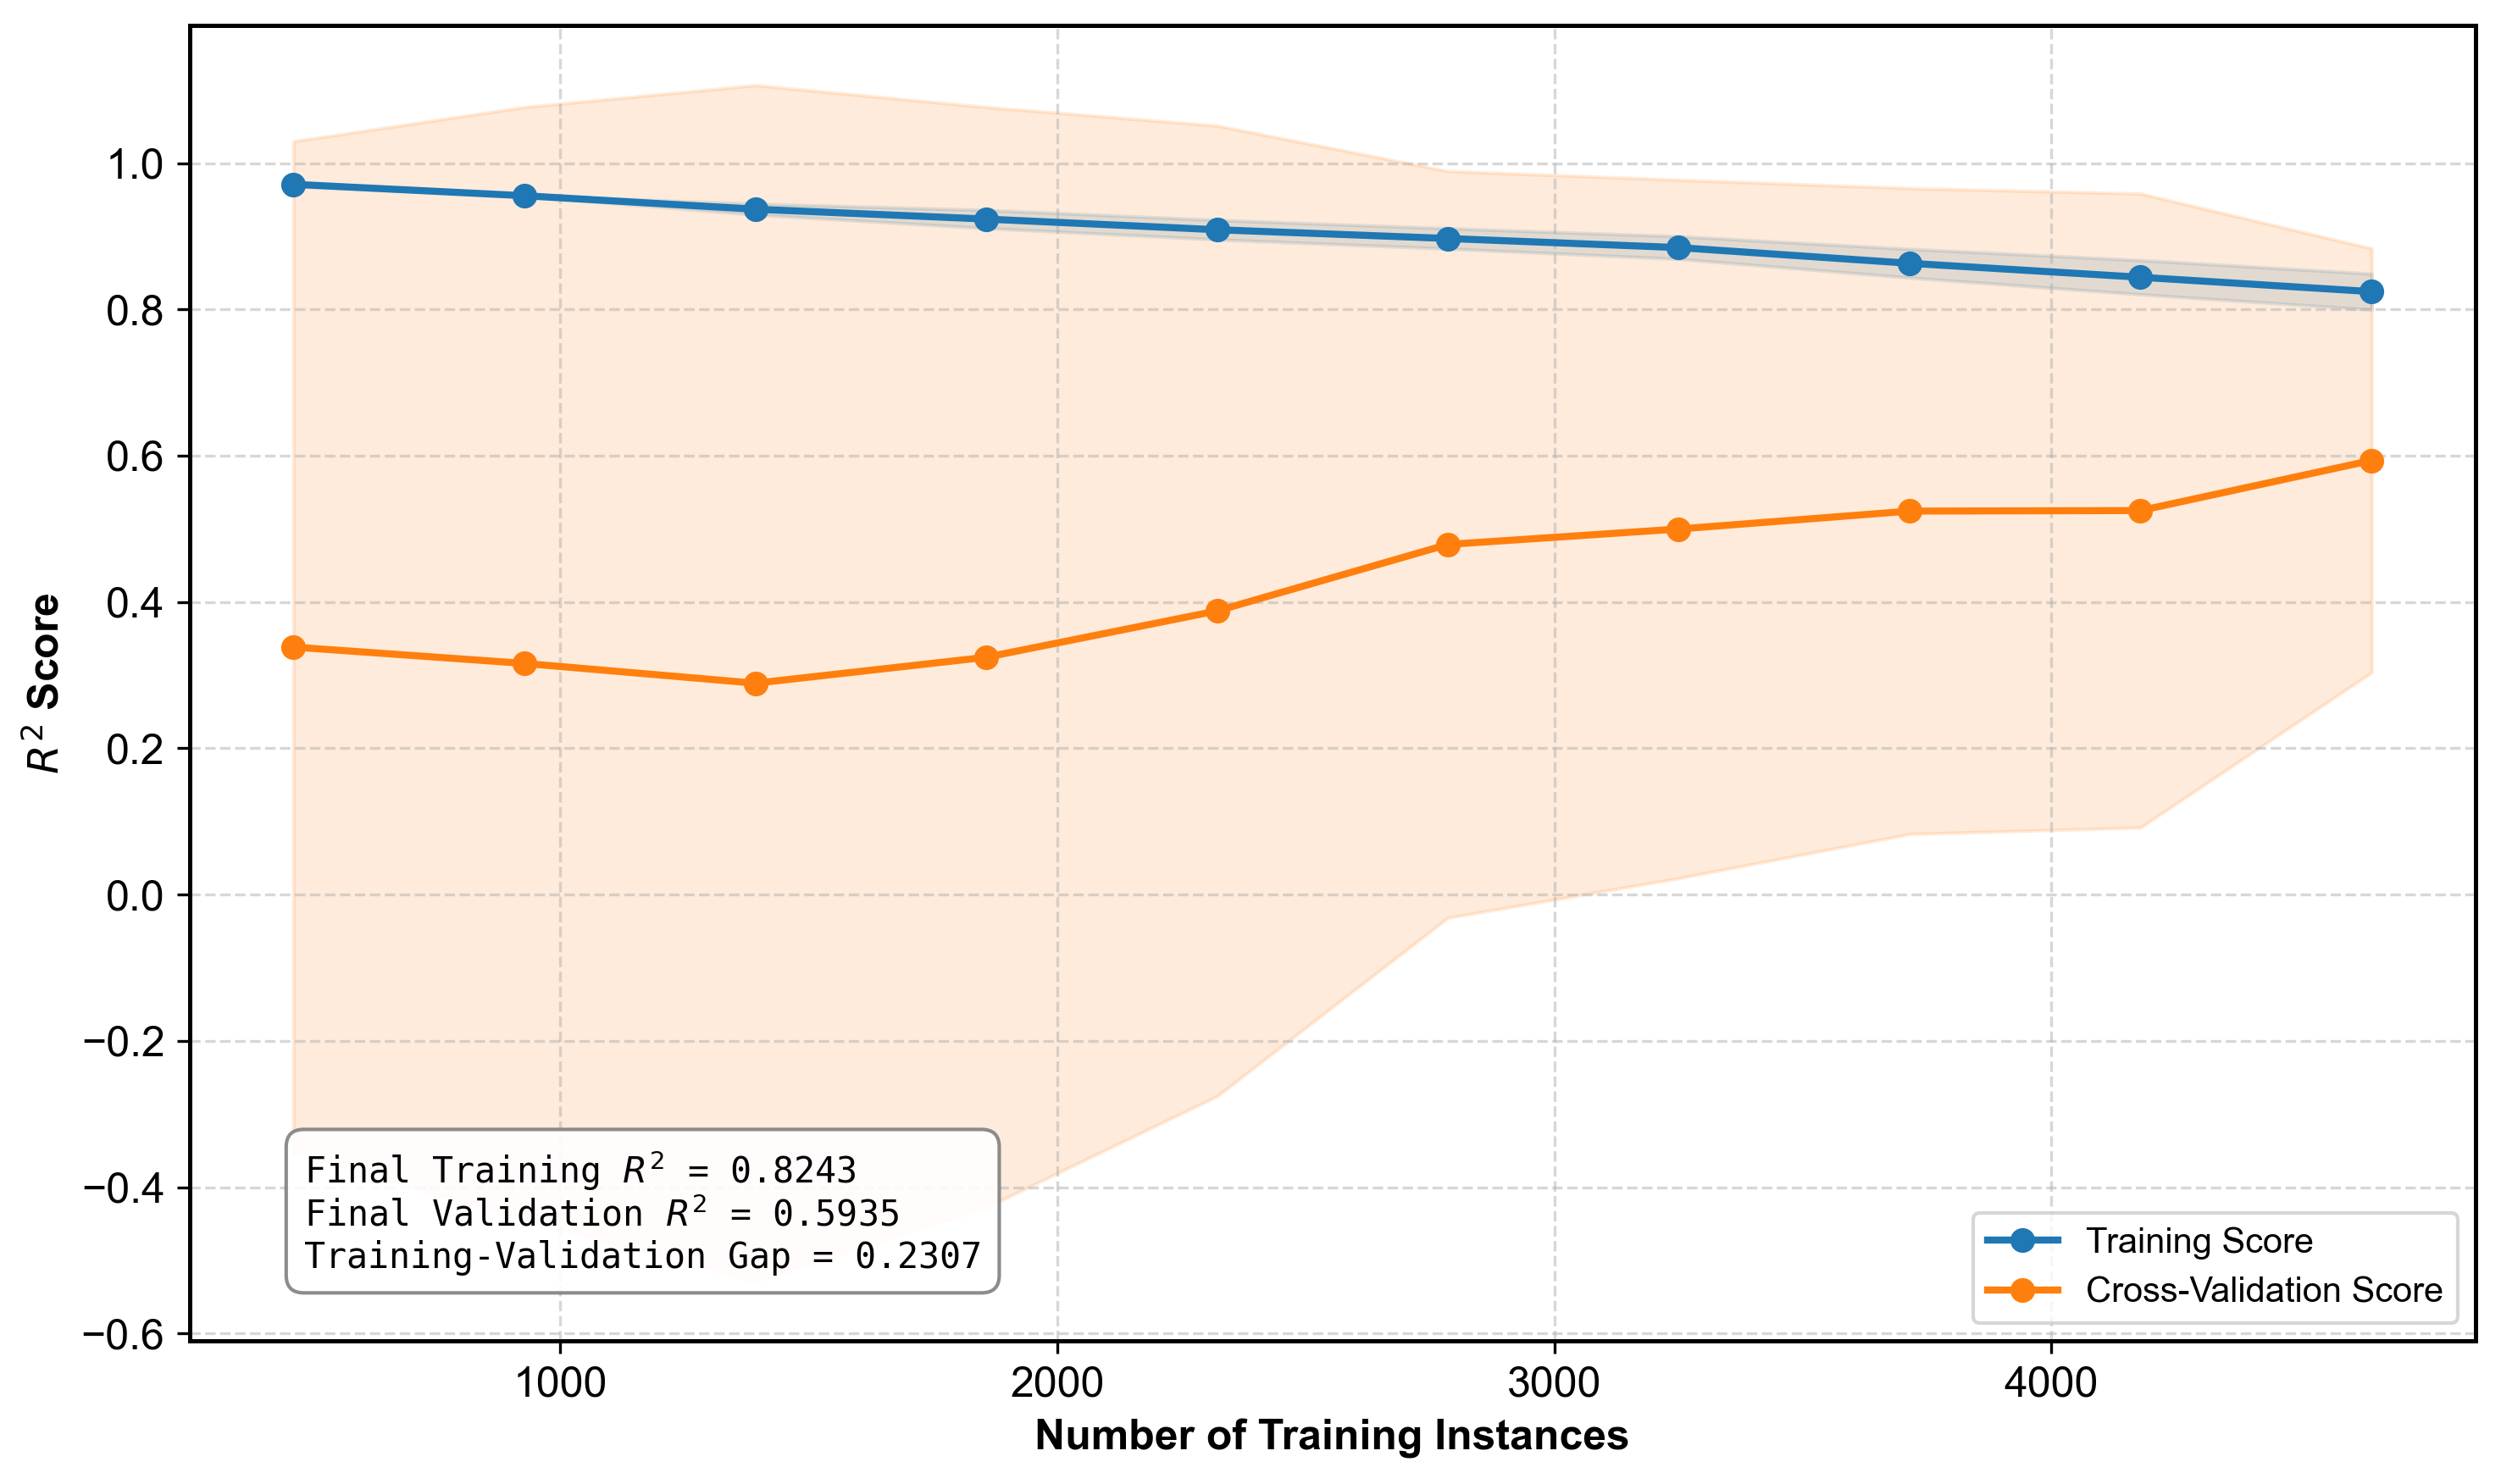

In [20]:
fig, ax = pl.plot_learning_curve(
    model=final_model, 
    X=X_train, 
    y=y_train, 
    cv=5, 
    save_path='./Plot/learning_curve_compact_catboost_260421.png'
)

In [21]:
import session_info

session_info.show()